In [12]:
import os
from glob import glob

import numpy as np
import pandas as pd
import scipy.io
import mne

from tqdm import tqdm

In [13]:
TDC = "CleanData_TDC"
IDD = "CleanData_IDD"

In [14]:
print("Current Working Directory:")
print(os.getcwd())

print("\nContents of TDC:")
print(os.listdir(TDC))

print("\nContents of IDD:")
print(os.listdir(IDD))

Current Working Directory:
c:\Users\Asus\BCI-EEG-Signal-Classification

Contents of TDC:
['Music', 'Rest', '_DS_Store']

Contents of IDD:
['Music', 'Rest', '_DS_Store']


In [15]:
tdc_music = sorted(glob(os.path.join(TDC, "Music", "*.mat")))
tdc_rest  = sorted(glob(os.path.join(TDC, "Rest", "*.mat")))

idd_music = sorted(glob(os.path.join(IDD, "Music", "*.mat")))
idd_rest  = sorted(glob(os.path.join(IDD, "Rest", "*.mat")))

print("TDC Music:", len(tdc_music))
print("TDC Rest :", len(tdc_rest))
print("IDD Music:", len(idd_music))
print("IDD Rest :", len(idd_rest))

TDC Music: 7
TDC Rest : 7
IDD Music: 7
IDD Rest : 8


In [16]:
print("First TDC Music file:")
print(tdc_music[0])

First TDC Music file:
CleanData_TDC\Music\CGS01_Music_CD.mat


In [17]:
data = scipy.io.loadmat(tdc_music[0])

In [18]:
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'clean_data'])


In [19]:
eeg = data["clean_data"]

print(eeg.shape)

(14, 15360)


In [30]:
import mne

sampling_freq = 128

ch_names = [
    'AF3','F7','F3','FC5',
    'T7','P7','O1','O2',
    'P8','T8','FC6','F4',
    'F8','AF4'
]

ch_types = ['eeg'] * len(ch_names)

def convert_mat_to_epochs(eeg):

    info = mne.create_info(
        ch_names=ch_names,
        sfreq=sampling_freq,
        ch_types=ch_types
    )

    info.set_montage("standard_1020")

    raw = mne.io.RawArray(eeg, info, verbose=False)

    raw.set_eeg_reference(verbose=False)

    raw.filter(
        l_freq=1,
        h_freq=30,
        verbose=False
    )

    epochs = mne.make_fixed_length_epochs(
        raw,
        duration=4,
        overlap=0,
        preload=True,
        verbose=False
    )

    return epochs.get_data()

In [31]:
raw = mne.io.RawArray(eeg, info)

raw

Creating RawArray with float64 data, n_channels=14, n_times=15360
    Range : 0 ... 15359 =      0.000 ...   119.992 secs
Ready.


<RawArray | 14 x 15360 (120.0 s), ~1.7 MiB, data loaded>

Using matplotlib as 2D backend.


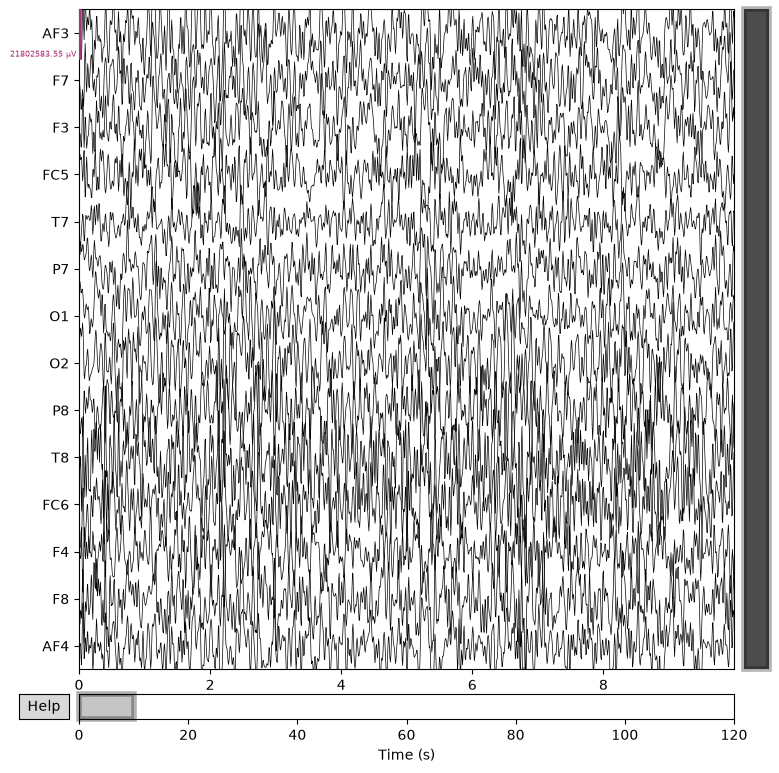

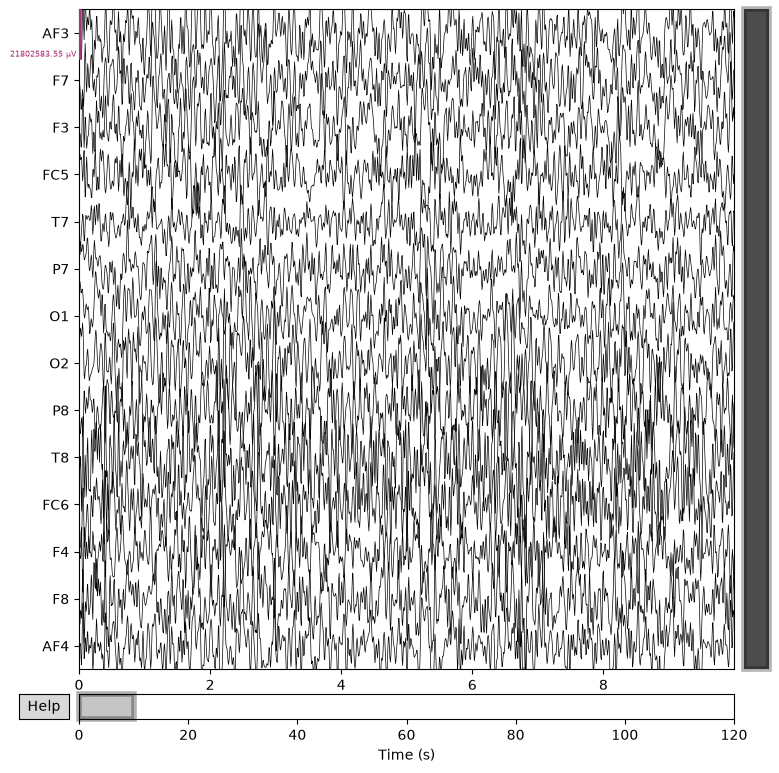

In [23]:
raw.plot(duration=10, scalings='auto')

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Asus\BCI-EEG-Signal-Classification\env\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


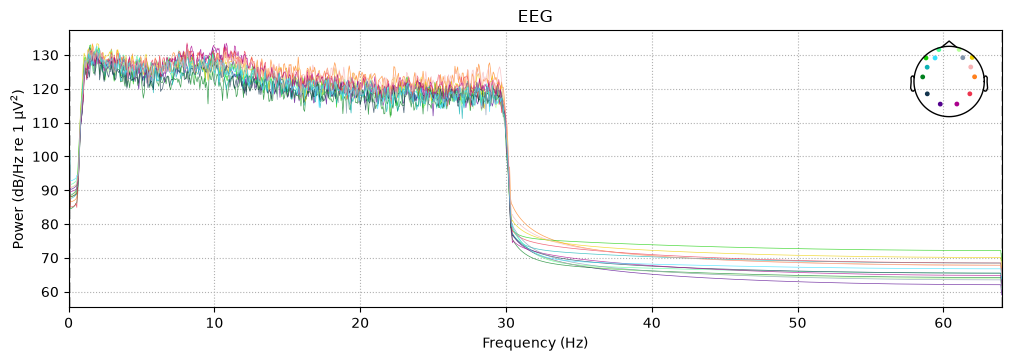

In [24]:
raw.compute_psd().plot()

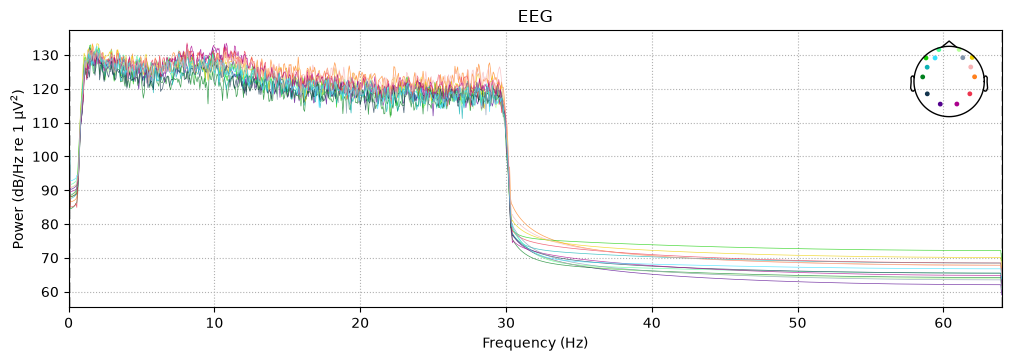

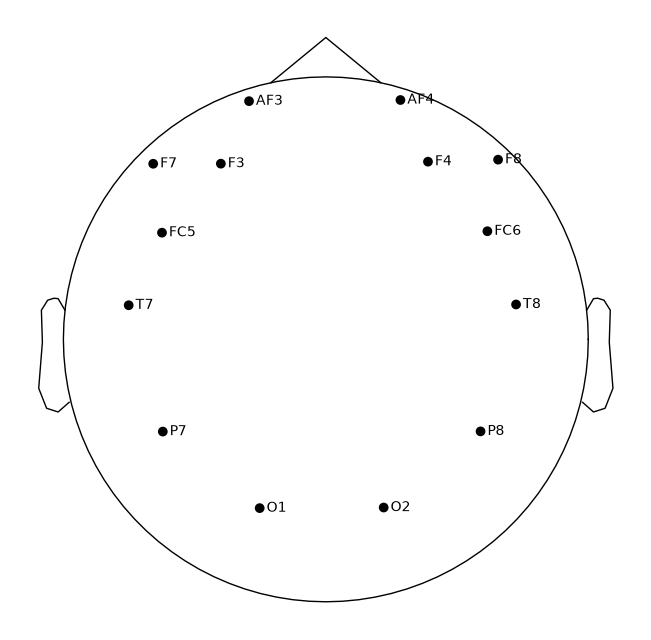

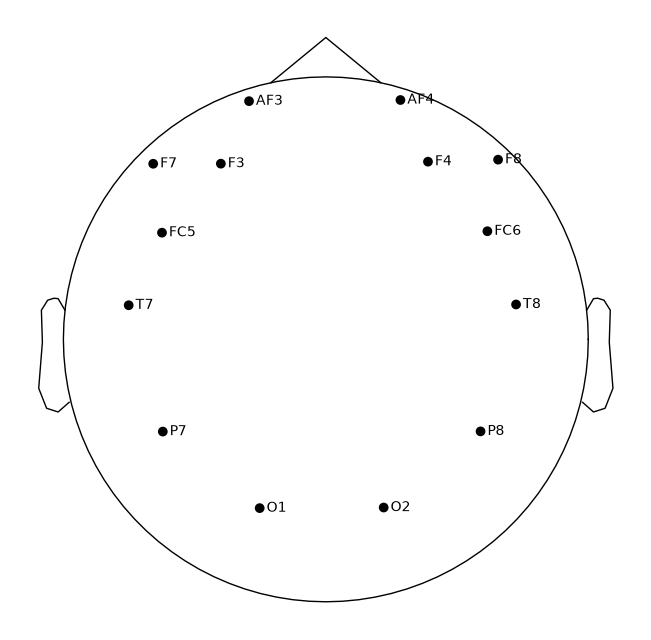

In [25]:
raw.plot_sensors(show_names=True)

In [26]:
epochs = mne.make_fixed_length_epochs(
    raw,
    duration=4,
    overlap=0,
    preload=True
)

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 512 original time points ...
0 bad epochs dropped


In [28]:
epochs_data = epochs.get_data()

print(epochs_data.shape)

(30, 14, 512)


In [32]:
epochs = convert_mat_to_epochs(eeg)

print(epochs.shape)

(30, 14, 512)


In [33]:
idd_subjects = []

for file in glob(IDD + "/Rest/*.mat"):
    eeg = scipy.io.loadmat(file)["clean_data"]
    epochs = convert_mat_to_epochs(eeg)
    idd_subjects.append(epochs)

print("IDD Subjects:", len(idd_subjects))

IDD Subjects: 8


In [34]:
tdc_subjects = []

for file in glob(TDC + "/Rest/*.mat"):
    eeg = scipy.io.loadmat(file)["clean_data"]
    epochs = convert_mat_to_epochs(eeg)
    tdc_subjects.append(epochs)

print("TDC Subjects:", len(tdc_subjects))

TDC Subjects: 7


In [35]:
print(len(idd_subjects))
print(len(tdc_subjects))

8
7


In [36]:
print(idd_subjects[0].shape)
print(tdc_subjects[0].shape)

(30, 14, 512)
(30, 14, 512)


In [42]:
import numpy as np
import torch

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

from torch.utils.data import TensorDataset, DataLoader

In [43]:
class StandardScaler3D(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.scaler = StandardScaler()

    def fit(self, X, y=None):
        self.scaler.fit(X.reshape(-1, X.shape[2]))
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(
            X.reshape(-1, X.shape[2])
        )
        return X_scaled.reshape(X.shape)

In [44]:
data_list = []
label_list = []
group_list = []

subject_id = 0

# IDD = label 1
for subject in idd_subjects:

    data_list.append(subject)

    label_list.append(
        np.ones(subject.shape[0], dtype=int)
    )

    group_list.append(
        np.full(subject.shape[0], subject_id)
    )

    subject_id += 1


# TDC = label 0
for subject in tdc_subjects:

    data_list.append(subject)

    label_list.append(
        np.zeros(subject.shape[0], dtype=int)
    )

    group_list.append(
        np.full(subject.shape[0], subject_id)
    )

    subject_id += 1

In [45]:
data_array = np.concatenate(data_list)

label_array = np.concatenate(label_list)

group_array = np.concatenate(group_list)

In [46]:
print(data_array.shape)
print(label_array.shape)
print(group_array.shape)

(450, 14, 512)
(450,)
(450,)


In [47]:
gkf = GroupKFold(n_splits=5)

In [48]:
for train_idx, val_idx in gkf.split(
    data_array,
    label_array,
    groups=group_array
):

    train_features = data_array[train_idx]
    train_labels = label_array[train_idx]

    val_features = data_array[val_idx]
    val_labels = label_array[val_idx]

    break

In [49]:
scaler = StandardScaler3D()

train_features = scaler.fit_transform(train_features)

val_features = scaler.transform(val_features)

In [50]:
print(train_features.shape)

(360, 14, 512)


In [51]:
train_features = np.moveaxis(train_features, 1, 2)
val_features = np.moveaxis(val_features, 1, 2)

In [52]:
train_features = torch.tensor(train_features, dtype=torch.float32)

val_features = torch.tensor(val_features, dtype=torch.float32)

train_labels = torch.tensor(train_labels, dtype=torch.long)

val_labels = torch.tensor(val_labels, dtype=torch.long)

In [53]:
print(len(train_features), len(train_labels))

print(len(val_features), len(val_labels))

print(train_features.shape)

print(val_features.shape)

360 360
90 90
torch.Size([360, 512, 14])
torch.Size([90, 512, 14])


In [54]:
train_dataset = TensorDataset(
    train_features,
    train_labels
)

val_dataset = TensorDataset(
    val_features,
    val_labels
)

In [55]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)